In [1]:
import tensorflow as tf
#import levenberg_marquardt as lm
import scipy.stats
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import seaborn as sns
from glob import glob
import xarray as xr
#import typhon as ty
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/')
print(sys.path)
#import src

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

2025-04-11 15:51:27.159857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744379487.313642 3998225 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744379487.340320 3998225 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-11 15:51:27.622166: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


['/home/u/u301032/lib/python', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python312.zip', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/lib-dynload', '', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/setuptools/_vendor', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/']


## Load preprocessed training data

In [2]:
name_pamtra_run = "all_area_1000th_cell" # "cells_025x025_2h"
data=[]
names=['TBs', 'IWV', 'IWP', 'LWP','t_steps','cell_selection']
for i in range(len(names)):
    data.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_' + names[i] + '.npy'))
TBs, IWV, IWP, LWP,t_steps,cell_selection =data

#### Filter for unrealistic BTs missing

In [3]:
TB_input_vector=TBs
"""
# exclude profiles with unrealistic pamtra simulations
TBs[TBs[:,20]<230] = np.nan   # TODO what are in our case unrealistic values?
TB_input_vector = TBs[~np.isnan(TBs).any(axis=1),:] #TODO: count NANs. If NAN do not just drop , as index would get messed up
IWP = IWP[~np.isnan(TBs).any(axis=1)]
LWP = LWP[~np.isnan(TBs).any(axis=1)]
IWV = IWV[~np.isnan(TBs).any(axis=1)]
"""
if np.count_nonzero(np.isnan(TBs)) > 0:
    print("NaN values in Brightnesstemperature array. This may influence the rest of the Retrievaldeveloment, as they are not being filtered.")


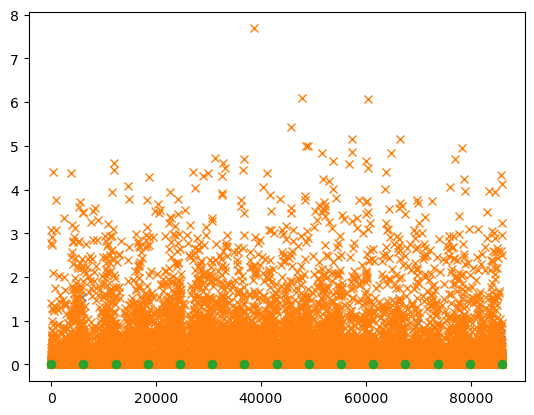

array(['2024-08-24T12:00:00.000000000', '2024-08-24T16:00:00.000000000',
       '2024-08-24T20:00:00.000000000', '2024-08-25T00:00:00.000000000',
       '2024-08-25T04:00:00.000000000', '2024-08-29T12:00:00.000000000',
       '2024-08-29T16:00:00.000000000', '2024-08-29T20:00:00.000000000',
       '2024-08-30T00:00:00.000000000', '2024-09-27T12:00:00.000000000',
       '2024-09-27T16:00:00.000000000', '2024-09-27T20:00:00.000000000',
       '2024-09-28T00:00:00.000000000', '2024-09-28T04:00:00.000000000'],
      dtype='datetime64[ns]')

In [4]:
# set IWP values below 1gm2 to zero #TODO check what this means in tropics eg literature, histograms
#IWP[IWP<1.]=0.
#Das würde fast alle IWPs auf 0 setzen, da:
plt.plot(IWP,'x')
plt.show()
#check how different the subsets are:
x=np.arange(0,TB_input_vector.shape[0]+1,TB_input_vector.shape[0]/len(t_steps))
plt.plot(LWP,'x')
plt.plot(x,np.zeros_like(x),'o')
plt.show()
t_steps

In [5]:
TBs.shape
# Only necessary if one wants to exclude certain frequencies.
TB_input_vector = np.concatenate((
        TB_input_vector[:,0:7], # K-Band
        TB_input_vector[:,7:14], # V-Band
        TB_input_vector[:,14:15], # W-Band
        TB_input_vector[:,15:19], # F-Band
        TB_input_vector[:,19:]), # G-Band
        axis=1)
TB_input_vector.shape

if (len(t_steps)*len(cell_selection)!=(TB_input_vector.shape[0])):
    print("Shape of TB does not match cell and time steps. Please check.")

len(t_steps)

14

### Splitting Tesst and Trainings Data
#### Here timestepwise

In [6]:
def splitting_in_train_test_validate(A,t_steps,slices_train,slices_validate,slices_test):    
    # Splits in timesteps
    x=np.arange(0,A.shape[0]+1,A.shape[0]/len(t_steps))
    x=x.astype(int)
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_train])
    train=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_validate])
    validate=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_test])
    test=  A[indexes]
    
    return train,test,validate

slices_train=[[0,2],[4,6],[8,10],[12,14]]
slices_validate=[[2,3],[7,8],[10,11]]
slices_test=[[3,4],[6,7],[11,12]]


train_TB, test_TB, validate_TB = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
train_IWV, test_IWV, validate_IWV = splitting_in_train_test_validate(IWV,t_steps,slices_train,slices_validate,slices_test)
train_LWP, test_LWP, validate_LWP = splitting_in_train_test_validate(LWP,t_steps,slices_train,slices_validate,slices_test)
train_IWP, test_IWP, validate_IWP = splitting_in_train_test_validate(IWP,t_steps,slices_train,slices_validate,slices_test)

### Standardizing Input
##### standardize all TBs along their respective channel as a normal distribution with mean 0 and std of 1

In [7]:
def standardize_nn_training_data(TBs_train):
        
    TBs_centered = np.zeros(TBs_train.shape)
    mu_train = np.zeros(TBs_train.shape[1])
    sigma_train = np.zeros(TBs_train.shape[1])
    for channel in range(TBs_train.shape[1]):

        mu_train[channel] = np.nanmean(TBs_train[:,channel])
        sigma_train[channel] = np.nanstd(TBs_train[:,channel])   

        TBs_centered[:,channel] = (TBs_train[:,channel] - mu_train[channel])/sigma_train[channel]
        
    return TBs_centered, mu_train, sigma_train
    
def standardize_nn_input_data_v2(TBs, mu, sigma):
    
    TBs = np.asarray(TBs)
    # if single TB observation provided extend dims to 2
    if len(TBs.shape) == 1:
        TBs = TBs[np.newaxis,:]
    
    TBs_centered = np.zeros(TBs.shape)
    for channel in range(TBs.shape[1]):

        TBs_centered[:,channel] = (TBs[:,channel] - mu[channel])/sigma[channel]
    
    return TBs_centered
    

TBs_train_scaled, mu_train, sigma_train = standardize_nn_training_data(train_TB) 
TBs_test_scaled = standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 
TBs_validate_scaled = standardize_nn_input_data_v2(validate_TB,mu=mu_train,sigma=sigma_train)

#### Definition & compilation of network

In [8]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50

In [51]:
# define & compile nn-model for iwp with specified settings
# * 1 input layer (24 neurons) 
# * 1 hidden layer (64 neurons)
# * 1 output layer (1 neuron)
TBs_train=train_TB
dnn_model_iwp = tf.keras.Sequential([
    tf.keras.layers.Dropout(rate=0.05, input_shape=(TBs_train.shape[1],)),
    tf.keras.layers.Dense(NR_of_NEURONS_L1,
                          input_shape=(TBs_train.shape[1],),
                          bias_initializer=BIAS_INIT,
                          kernel_initializer=WEIGHT_INIT,
                          kernel_regularizer="l2",
                          activation=ACTIVATION_HL,
                         ),
    tf.keras.layers.Dense(1,
                          activation=ACTIVATION_OP)])

dnn_model_iwp.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                      loss=LOSS_FUNCTION,
                     )

dnn_model_iwp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_3 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Training of IWP neural network

CPU times: user 1min 3s, sys: 2.98 s, total: 1min 6s
Wall time: 48.4 s


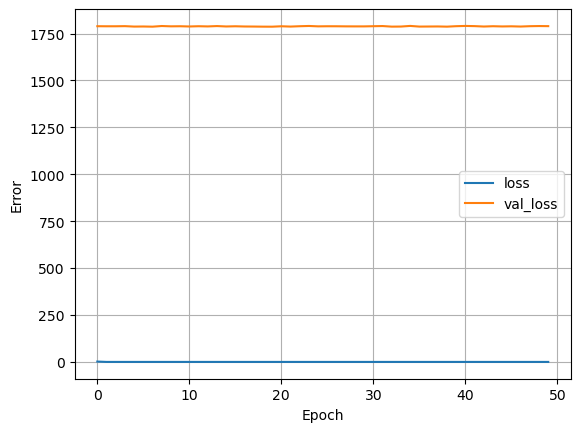

In [66]:
%%time

train_hyd =train_IWV #Hyd to train
test_hyd=test_IWV # Hyd to test
validate_hyd=validate_IWV
history = dnn_model_iwp.fit(
    #TBs_train_scaled, np.sqrt(train_hyd),
    validation_split=0.2,
    validation_data=(TBs_validate_scaled,validate_hyd),#new
    verbose=0,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)]
)

# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
#plt.ylim(0,40)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.grid(True)
plt.legend()

#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_training_error_loss_24-32-1.jpg',bbox_inches='tight',dpi=200)

### NN-IWP performance on PAMTRA test dataset

In [67]:
# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
##IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
##IWP_test_predictions_squared = IWP_test_predictions_cliped**2
IWP_test_predictions_squared =IWP_test_predictions**2

576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step


In [68]:
IWP_test_predictions

array([7.728, 7.708, 7.711, ..., 6.334, 6.567, 6.41 ],
      shape=(18417,), dtype=float32)

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3998225/59705641.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sqrt{IWP}$")


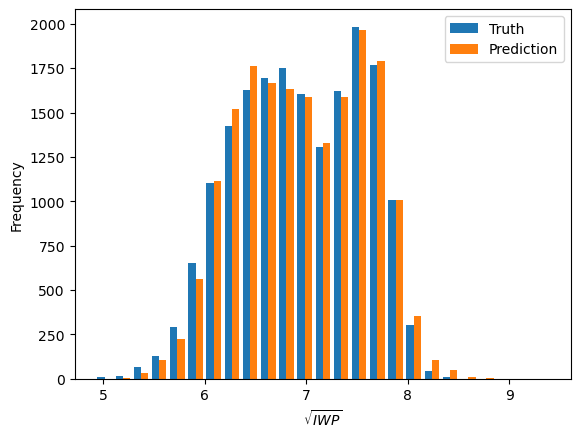

In [69]:
# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

fig, ax = plt.subplots()

labels = [
    f"Truth",
    "Prediction",
    "Prediction (cliped)"]
ax.hist(np.array([np.sqrt(test_hyd),IWP_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
#ax.text(35.,3000,"$\overline{Truth}=$"+str(np.round(np.nanmean(np.sqrt(IWP_test)),2))+"$\sqrt{g}m^{-1}$",ha="left")
#ax.text(35.,2700,"$\overline{Prediction}=$"+str(np.round(np.mean(IWP_test_predictions),2))+"$\sqrt{g}m^{-1}$",ha="left")
##ax.text(35.,2400,"$\overline{Prediction (cliped)}=$"+str(np.round(np.mean(IWP_test_predictions_cliped),2))+"$\sqrt{g}m^{-1}$",ha="left")
ax.set_xlabel("$\sqrt{IWP}$")
ax.set_ylabel("Frequency")
plt.legend()
plt.show()
#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_predictions_cliping_effect.jpg',bbox_inches='tight',dpi=200)

In [39]:
a.max()

np.float32(0.9384548)

bias:  0.3  corr:  0.99  rmse:  1.13


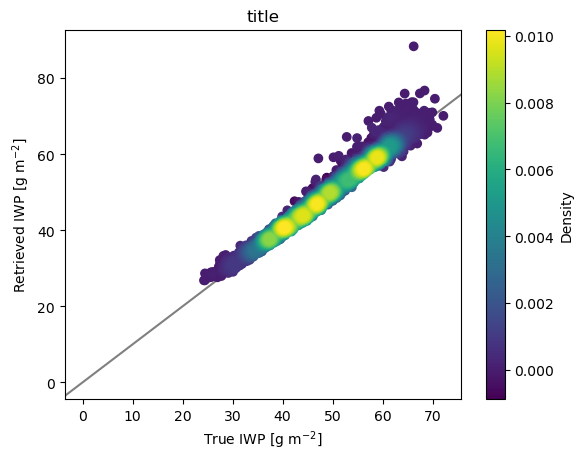

In [70]:
a = test_hyd
b = IWP_test_predictions_squared
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]
bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)
print('bias: ',bias,' corr: ',corr,' rmse: ',rmse)
from matplotlib import cm
from scipy.interpolate import interpn
from matplotlib.colors import Normalize 
density_scatter(a,b,xlabel='True IWP [g m$^{-2}$]',ylabel='Retrieved IWP [g m$^{-2}$]' )
plt.show()

In [41]:
  def density_scatter( x , y, ax = None, sort = True, bins = 20,title="title",xlabel="x",ylabel="y",lim=None, **kwargs )   :
      """
      Scatter plot colored by 2d histogram
      """
      
      
      if ax is None :
          fig , ax = plt.subplots()
      ax.axline((0,0),slope=1,color="grey", zorder=1)
      data , x_e, y_e = np.histogram2d( x, y, bins = bins, density = True )
      z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ) , data , np.vstack([x,y]).T , method = "splinef2d", bounds_error = False)

      #To be sure to plot all data
      z[np.where(np.isnan(z))] = 0.0

      # Sort the points by density, so that the densest points are plotted last
      if sort :
          idx = z.argsort()
          x, y, z = x[idx], y[idx], z[idx]

      ax.scatter( x, y, c=z, **kwargs )

      norm = Normalize(vmin = np.min(z), vmax = np.max(z))
      cbar = fig.colorbar(cm.ScalarMappable(norm = norm), ax=ax)
      if lim != None:
          ax.set_xlim(lim)
          ax.set_ylim(lim)
      cbar.ax.set_ylabel('Density')
      ax.set_xlabel(xlabel)
      ax.set_ylabel(ylabel)
      ax.set_title(str(title))

      return ax

<>:116: SyntaxWarning: invalid escape sequence '\s'
<>:117: SyntaxWarning: invalid escape sequence '\s'
<>:116: SyntaxWarning: invalid escape sequence '\s'
<>:117: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3998225/875903870.py:116: SyntaxWarning: invalid escape sequence '\s'
  axs.set_xlabel('$\sqrt{IWP}$ [$\sqrt{g}m^{-1}$] - True (ICON)')
/tmp/ipykernel_3998225/875903870.py:117: SyntaxWarning: invalid escape sequence '\s'
  axs.set_ylabel('$\sqrt{IWP}$ [$\sqrt{g}m^{-1}$] - NN predictions')


LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

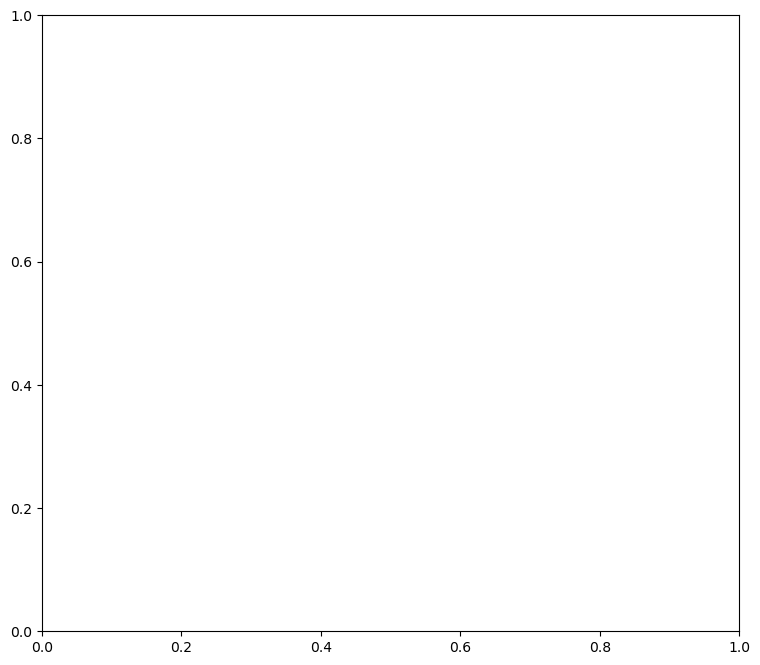

In [25]:
# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

kind = 'log'

fig, axs = plt.subplots(figsize=(9,8))

if kind == 'linear':
    
    a = IWP_test
    b = IWP_test_predictions_squared
    
    a[a<1.] = 0
    b[b<1.] = 0
    
    #a[a<1.] = np.nan
    #b[b<1.] = np.nan
    
if kind == 'log':
    
    IWP_test_log = IWP_test.copy()
    IWP_test_log[IWP_test_log==0] = 10**(-16)
    IWP_test_predictions_squared_log = IWP_test_predictions_squared.copy()
    IWP_test_predictions_squared_log[IWP_test_predictions_squared_log==0] = 10**(-16)
    
    a = np.log10(IWP_test_log)
    b = np.log10(IWP_test_predictions_squared_log)
    
    a[a<0.] = 0
    b[b<0.] = 0
    
    #a[a<0.] = np.nan
    #b[b<0.] = np.nan
    
    #a = IWP_test.copy()
    #b = IWP_test_predictions_squared.copy()
    
    #a[a<1.] = 1.
    #b[b<1.] = 1.
    
if kind == 'sqrt':
    
    a = np.sqrt(IWP_test)
    b = IWP_test_predictions

nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]

maxval = max(np.max(a),np.max(b))
minval = max(np.min(a),np.min(b))
    
# Calculate the point density
ab = np.vstack([a,b])
c = scipy.stats.gaussian_kde(ab)(ab)

# Sort the points by density, so that the densest points are plotted last
idx = c.argsort()
a, b, c = a[idx], b[idx], c[idx]

bias = np.round((np.mean(b) - np.mean(a)),2)
corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)

axs.grid(alpha=0.5,which='both')

iwp_true = np.arange(1,np.nanmax(IWP_test),0.01)
RE_80_plus = (0.8*iwp_true)+iwp_true
RE_80_minus = (-0.8*iwp_true)+iwp_true
RE_50_plus = (0.5*iwp_true)+iwp_true
RE_50_minus = (-0.5*iwp_true)+iwp_true
RE_20_plus = (0.2*iwp_true)+iwp_true
RE_20_minus = (-0.2*iwp_true)+iwp_true
RE_20_minus[RE_20_minus<1.]=np.nan
RE_50_minus[RE_50_minus<1.]=np.nan
RE_80_minus[RE_80_minus<1.]=np.nan
  
#axs.scatter(y_test, y_test_predictions**2)
if kind == 'linear':
    sc = axs.scatter(a,b,c=c,s=5,cmap='viridis',vmin=np.min(c),vmax=0.00004)
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(iwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.5,label='±20%')
    axs.plot(iwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.5)
    axs.plot(iwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.5,label='±50%')
    axs.plot(iwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.5)
    axs.plot(iwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5,label='±80%')
    axs.plot(iwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.5)
    
    axs.set_xlabel('IWP [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('IWP [g m$^{-2}$] - NN Predictions')
    axs.set_ylim(top=3200)
    axs.set_xlim(right=3200)
    
if kind == 'log':
    sc = axs.scatter(10**a,10**b,c=c,s=15,cmap='viridis',vmin=0,vmax=0.4)
    #sc = axs.scatter(a,b,c=c,s=8,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(10**0,10**maxval),np.arange(10**0,10**maxval),linewidth=3,color='black',alpha=1,label='1:1')
    #axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    axs.plot(iwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
    axs.plot(iwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)
    axs.plot(iwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±50%')
    axs.plot(iwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
    axs.plot(iwp_true,RE_80_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9,label='±80%')
    axs.plot(iwp_true,RE_80_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9)
    
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_xlabel('IWP [g m$^{-2}$] - True (ICON)')
    axs.set_ylabel('IWP [g m$^{-2}$] - NN Predictions')
    #axs.set_ylim(bottom=1)
    #axs.set_xlim(left=1)

if kind == 'sqrt':
    sc = axs.scatter(a,b,c=c,s=15,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
    axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=2,color='black',alpha=0.5)
    axs.set_xlabel('$\sqrt{IWP}$ [$\sqrt{g}m^{-1}$] - True (ICON)')
    axs.set_ylabel('$\sqrt{IWP}$ [$\sqrt{g}m^{-1}$] - NN predictions')
    
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Point density',size=20)
axs.legend()

#axs.text(0.02, 0.8, 'Bias: '+str(bias), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.885, 'RMSE: '+str(rmse), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')
#axs.text(0.05, 0.81, 'Corr: '+str(corr), 
#         transform=axs.transAxes, fontsize=20,
#         verticalalignment='top')

print('Bias: '+str(bias))
print('RMSE: '+str(rmse))
print('Corr: '+str(corr))

#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_24_32_1_reg_12000m_testdata_scatterdensity_linear.jpg',bbox_inches='tight',dpi=200)

Text(62.597222222222214, 0.5, 'Retrieved IWP [g m$^{-2}$]')

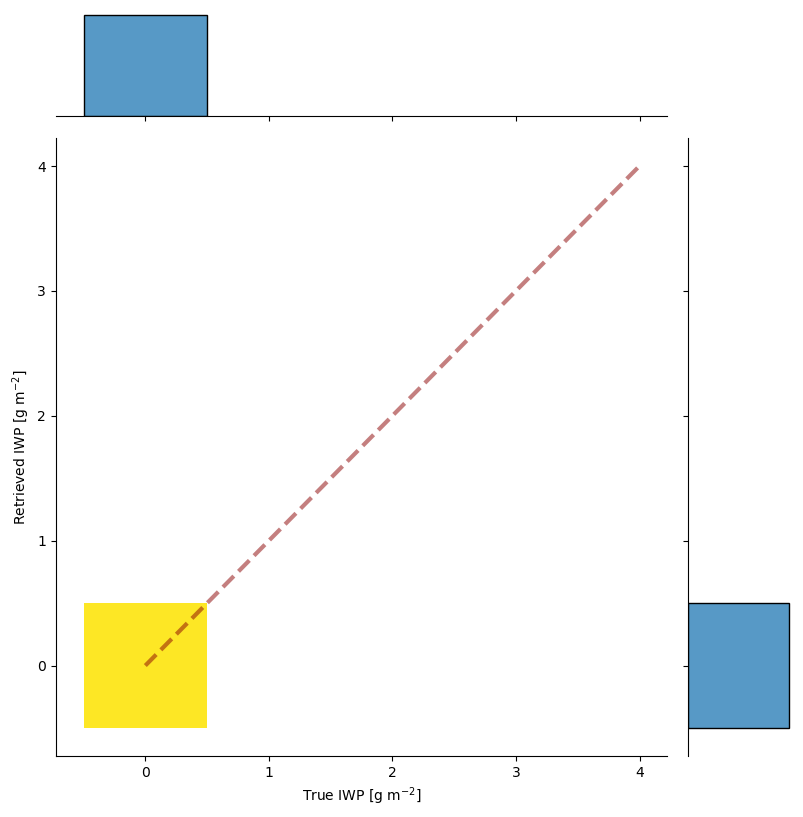

In [27]:
kind = 'log'

if kind == 'linear':
    
    a = IWP_test
    b = IWP_test_predictions_squared
    
    a[a<1.] = 0
    b[b<1.] = 0
    
    #a[a<1.] = np.nan
    #b[b<1.] = np.nan
    
if kind == 'log':
    
    IWP_test_log = IWP_test.copy()
    IWP_test_log[IWP_test_log==0] = 10**(-16)
    #IWP_test_log[IWP_test_log<1] = np.nan
    IWP_test_predictions_squared_log = IWP_test_predictions_squared.copy()
    IWP_test_predictions_squared_log[IWP_test_predictions_squared_log==0] = 10**(-16)
    #IWP_test_predictions_squared_log[IWP_test_predictions_squared_log<1] = np.nan
    
    a = np.log10(IWP_test_log)
    b = np.log10(IWP_test_predictions_squared_log)
    
    a[a<0.] = 0
    b[b<0.] = 0
    
    #a[a<0.] = np.nan
    #b[b<0.] = np.nan
    
    #a = IWP_test.copy()
    #b = IWP_test_predictions_squared.copy()
    
    #a[a<1.] = 0.
    #b[b<1.] = 0.
    
if kind == 'sqrt':
    
    a = np.sqrt(IWP_test)
    b = IWP_test_predictions
    
maxval = max(np.nanmax(a),np.nanmax(b))
    
#a[a<0.] = 0
#b[b<0.] = 0

#f, ax = plt.subplots()

#sns.set(color_codes=True)

jp = sns.jointplot(x = a, y = b,
                   kind = "hist", data = None, cmap='viridis',vmin=0, vmax=60, height=8,)
jp.ax_joint.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
#jp.ax_joint.plot(iwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
#jp.ax_joint.plot(iwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)
#jp.ax_joint.plot(iwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±50%')
#jp.ax_joint.plot(iwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
#jp.ax_joint.plot(iwp_true,RE_100_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9,label='±100%')
#jp.ax_joint.plot(iwp_true,RE_100_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9)
#jp.ax_joint.set_xlim(0,maxval)
#jp.ax_joint.set_ylim(0,maxval)
#jp.ax_joint.set_xscale('log')
#jp.ax_joint.set_yscale('log')
jp.ax_joint.plot(np.arange(0,4.5),np.arange(0,4.5),linewidth=3,linestyle='dashed',color='darkred',alpha=0.5)
jp.ax_joint.set_xlabel('True IWP [g m$^{-2}$]')
jp.ax_joint.set_ylabel('Retrieved IWP [g m$^{-2}$]')
#plt.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=2,color='black',alpha=0.5)
#plt.xscale('log')
#plt.yscale('log')

#sns.set(color_codes=False)

#plt.savefig('/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/plot')

In [28]:
#IWP_test[IWP_test<1] = np.nan
#IWP_test_predictions_squared[IWP_test_predictions_squared<1] = np.nan

IWP_test_predictions_squared_clipped = IWP_test_predictions_squared.copy()
IWP_test_predictions_squared_clipped[IWP_test_predictions_squared_clipped<1.]=1.

IWP_test_clipped = IWP_test.copy()
IWP_test_clipped[IWP_test_clipped<1.]=1.

n_normed_ICON_clipped, ICON_zeros, bins  = src.normed_log10_pdf_v0(IWP_test_clipped,bin_nr=30)
n_normed_NN_clipped, NN_zeros, _ = src.normed_log10_pdf_v0(IWP_test_predictions_squared_clipped,bin_nr=30)
n_normed_ICON, bins  = src.normed_log10_pdf(IWP_test_clipped,bin_nr=30)
n_normed_NN, _ = src.normed_log10_pdf(IWP_test_predictions_squared_clipped,bin_nr=30)

# use typhon ploting style
plt.style.use(ty.plots.styles.get('typhon'))

fig, axs = plt.subplots()

axs.plot(10**bins[1:],n_normed_ICON_clipped,linewidth=3,color='black',label='Test data set - clipped')
axs.plot(10**bins[1:],n_normed_NN_clipped,linewidth=3,color='black',linestyle='dashed',label='NN Predictions - clipped')
#axs.plot(10**bins[1:],n_normed_ICON,linewidth=3,color='red',label='Test data set')
#axs.plot(10**bins[1:],n_normed_NN,linewidth=3,color='red',linestyle='dashed',label='NN Predictions')
axs.set_xscale('log')
#axs.set_yscale('log')
axs.legend()
axs.set_ylabel('Relative frequency')
axs.set_xlabel('IWP [g m$^{-2}$]')
xmin,xmax = axs.get_xlim()

#fig.suptitle('PAMTRA test dataset')

#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_24_32_1_reg_12000m_testdata_pdf.jpg',bbox_inches='tight',dpi=200)

NameError: name 'src' is not defined

In [14]:
sns.reset_orig

<function seaborn.rcmod.reset_orig()>

#### Saving NN-IWP model / retrieval to disk

In [14]:
dnn_model_iwp.save(f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_{altitude}m')

# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
IWP_test_predictions_squared = IWP_test_predictions_cliped**2

# Saving collocated ICON data to netcdf file
filename = (f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/train_test_data_nn_24-32-1_reg_{altitude}m.nc')
ds = Dataset(filename,'w','NETCDF4')

# profile and frequency dimensions
ds.createDimension('train_cases',len(IWP_train))
ds.createDimension('test_cases',len(IWP_test))
ds.createDimension('freq',24)

# TBs
tb_train_var = ds.createVariable('tb_train','float64',('train_cases','freq'))
tb_train_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of training data set'
tb_train_var.setncattr('units','K')
tb_train_var[:,:] = TBs_train[:,:]
tb_test_var = ds.createVariable('tb_test','float64',('test_cases','freq'))
tb_test_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of test data set'
tb_test_var.setncattr('units','K')
tb_test_var[:,:] = TBs_test[:,:]

# IWP
iwp_train_var = ds.createVariable('iwp_train','float64',('train_cases'))
iwp_train_var.long_name = 'ICON simulated IWP values of training data set'
iwp_train_var.setncattr('units','g m2')
iwp_train_var[:] = IWP_train[:]
iwp_test_var = ds.createVariable('iwp_test','float64',('test_cases'))
iwp_test_var.long_name = 'ICON simulated IWP values of test data set'
iwp_test_var.setncattr('units','g m2')
iwp_test_var[:] = IWP_test[:]
iwp_retr_var = ds.createVariable('iwp_retrieved','float64',('test_cases'))
iwp_retr_var.long_name = 'Retrieved IWP values of test data set'
iwp_retr_var.setncattr('units','g m2')
iwp_retr_var[:] = IWP_test_predictions_squared[:]

# LWP
lwp_train_var = ds.createVariable('lwp','float64',('train_cases'))
lwp_train_var.long_name = 'ICON simulated LWP values of training data set'
lwp_train_var.setncattr('units','g m2')
lwp_train_var[:] = LWP_train[:]
lwp_test_var = ds.createVariable('lwp_test','float64',('test_cases'))
lwp_test_var.long_name = 'ICON simulated LWP values of test data set'
lwp_test_var.setncattr('units','g m2')
lwp_test_var[:] = LWP_test[:]

# IWV
iwv_train_var = ds.createVariable('iwv','float64',('train_cases'))
iwv_train_var.long_name = 'ICON simulated IWV values of training data set'
iwv_train_var.setncattr('units','g m2')
iwv_train_var[:] = IWV_train[:]
iwv_test_var = ds.createVariable('iwv_test','float64',('test_cases'))
iwv_test_var.long_name = 'ICON simulated IWV values of test data set'
iwv_test_var.setncattr('units','g m2')
iwv_test_var[:] = IWV_test[:]

ds.close()

INFO:tensorflow:Assets written to: /home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_12500m/assets


INFO:tensorflow:Assets written to: /home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_12500m/assets


489/489 [==============================] - 0s 495us/step
Negative predictions: 1.5 %
